In [6]:
## Install Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

In [9]:
## Load Data Set
import pandas as pd

df = pd.read_csv( "/content/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [10]:
## Data inspection
print(df.info())

print(df.isnull().sum())

print(df["Churn"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
## convrt total charges to float
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

In [15]:
df["TotalCharges"].dtype


dtype('float64')

In [16]:
## Remove un-useful column
df.drop("customerID", axis=1, inplace=True)

In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

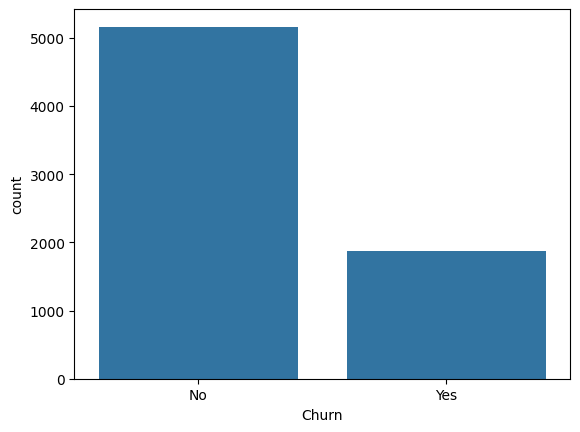

In [18]:
## EDA
## churn distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Churn",
    data=df
)

plt.show()

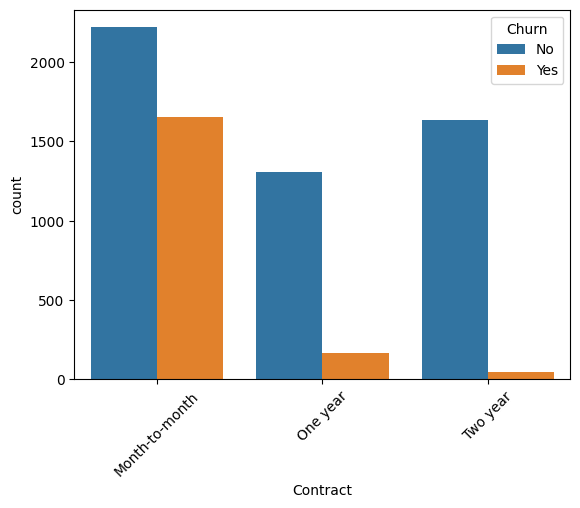

In [20]:
## Lets check Contract Type Vs Churn
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [21]:
## Feature Engineering
## convert target
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [22]:
## onehot encoding
df = pd.get_dummies(
    df,
    drop_first=True
)

In [23]:
df.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [25]:
## Train Test Split
from sklearn.model_selection import train_test_split
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
## Lets scaling the feature
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
## Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [28]:
##Prediction
y_pred = model.predict(
    X_test
)

In [29]:
##Model Evalution
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.7867803837953091
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [37]:
##Lets figureout the Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(
    importance.head(10)
)

                           feature  importance
3                     TotalCharges    0.194313
1                           tenure    0.168529
2                   MonthlyCharges    0.167972
10     InternetService_Fiber optic    0.038913
28  PaymentMethod_Electronic check    0.037898
25               Contract_Two year    0.031862
4                      gender_Male    0.028939
13              OnlineSecurity_Yes    0.027288
26            PaperlessBilling_Yes    0.025595
5                      Partner_Yes    0.023280


<Axes: ylabel='feature'>

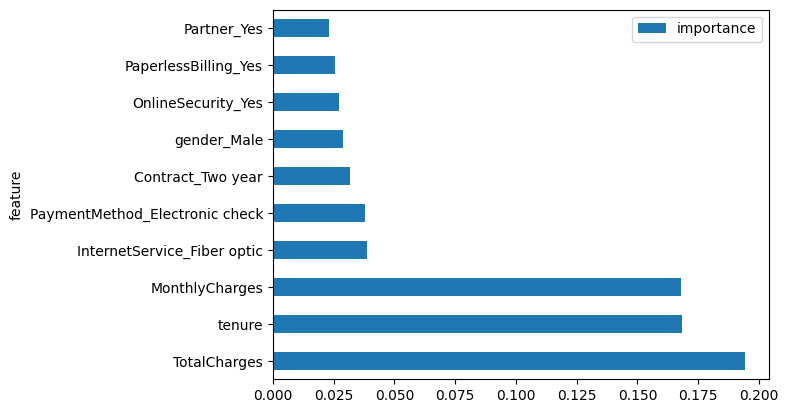

In [38]:
## Draw Importance Feature chart
importance.head(10).plot.barh(
    x="feature",
    y="importance"
)

In [40]:
### Save this model
import joblib

joblib.dump(
    model,
    "models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [43]:
import joblib
import pandas as pd


model = joblib.load("models/churn_model.pkl")
scaler = joblib.load("models/scaler.pkl")

print("Model loaded successfully!")

Model loaded successfully!
